### Essay Score and Feedback

In [161]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()
import os
from pydantic import BaseModel, Field
import operator

In [167]:
#creating llm
groq_api = os.getenv("GROQ_API_KEY")
llm = ChatGroq(groq_api_key=groq_api,model="llama-3.3-70b-versatile")

In [168]:
class EvaluateSchema(BaseModel):
    feedback:str = Field(description="Detailed text feedback only. Do not mention the numeric score here.")
    score:int = Field(description="Score out of 10",ge=0,le=10)

In [169]:
structured_llm = llm.with_structured_output(EvaluateSchema)

In [170]:
essay = '''Title: The Double-Edged Scalpel: The Promise and Perils of AI in Healthcare

Introduction

Medicine has always been an information science. From the scribbled notes of Hippocrates to the genomic sequences of today, the practice of healing relies on the synthesis of data. However, the volume of modern medical data—spanning electronic health records (EHRs), medical imaging, and genetic profiles—has surpassed the cognitive capacity of any single human physician. Enter Artificial Intelligence (AI). No longer just a futuristic concept, AI has become a tangible force in healthcare, acting as a "force multiplier" for medical professionals. While it offers unprecedented opportunities to revolutionize diagnostics, accelerate drug discovery, and personalize treatment, its rapid integration brings profound ethical and operational challenges that must be navigated with care.

The Diagnostic Revolution

One of the most immediate impacts of AI is in diagnostics, particularly within visual fields like radiology, pathology, and dermatology. Machine learning algorithms, specifically deep learning models, excel at pattern recognition. For instance, AI systems can now analyze chest X-rays or mammograms with accuracy rates that rival, and occasionally surpass, human experts. These tools do not suffer from fatigue or distraction, allowing for consistent screening of thousands of images to flag anomalies for human review.



Beyond imaging, AI is shifting healthcare from reactive to predictive. Predictive analytics models can analyze a patient's historical data to forecast life-threatening events like sepsis or heart failure hours before clinical symptoms appear. This "early warning system" allows clinicians to intervene sooner, potentially saving lives and reducing hospital stays.

Accelerating Drug Discovery

Perhaps the most transformative application of AI lies in pharmaceutical research. Traditional drug discovery is a notoriously slow and expensive process, often taking over a decade and billions of dollars to bring a single drug to market. AI is compressing this timeline by simulating biological interactions and predicting how potential drug molecules will behave in the human body.


Platforms like DeepMind’s AlphaFold have solved 50-year-old biological problems by predicting the 3D structures of nearly all known proteins. This capability allows researchers to design drugs "de novo" (from scratch) to target specific disease markers with high precision, rather than relying on trial-and-error screening.


The Era of Personalized Medicine

AI is the key to unlocking true personalized medicine. By integrating a patient's genetic makeup, lifestyle data, and environmental factors, AI models can tailor treatment plans to the individual. In oncology, for example, AI algorithms can analyze the genetic mutations of a tumor to recommend the specific combination of immunotherapies most likely to succeed for that specific patient, moving away from the "one-size-fits-all" approach of chemotherapy.

The Ethical Quagmire and Operational Challenges

Despite these benefits, the integration of AI is fraught with challenges. The most significant is the "Black Box" problem. Many deep learning models function as opaque boxes: data goes in, and a decision comes out, but the internal logic is often indecipherable even to its creators. In high-stakes medical scenarios, a doctor needs to know why an AI recommended a specific surgery or diagnosis to trust it.

Furthermore, AI systems are only as good as the data they are trained on. Historical biases in healthcare delivery can be encoded into algorithms. If an AI is trained predominantly on data from one demographic group, it may fail to diagnose conditions accurately in minority populations. There is also the looming issue of data privacy; training robust models requires massive datasets, raising concerns about the security of sensitive patient information and the potential for re-identification.




Conclusion

AI in healthcare represents a paradigm shift, not merely a technological upgrade. It holds the potential to democratize high-quality diagnostics, drastically reduce the cost of life-saving drugs, and free human clinicians from administrative drudgery to focus on patient care. However, realizing this future requires a "human-in-the-loop" approach. AI should be viewed not as a replacement for the physician, but as a powerful stethoscope for the 21st century—an instrument that, when guided by human empathy and ethical oversight, can hear the signals of disease more clearly than ever before. The future of medicine lies not in AI alone, but in "Augmented Intelligence"—the seamless collaboration between the algorithm and the healer.'''

In [171]:
structured_llm.invoke(essay).score

9

In [172]:
#defining State class
class CSSEssay(TypedDict):
    essay:str
    clarity_feedback:str
    language_feedback:str
    analysis_feedback:str
    overall_feedback:str
    individual_score:Annotated[list[int],operator.add]
    avg_score:float

In [173]:
#clarity_feedback_node
def clarity_feedback_node(state:CSSEssay):
    prompt=f"Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']} "
    output = structured_llm.invoke(prompt)
    print(output.score)
    return {"clarity_feedback":output.feedback,"individual_score": [output.score]}

In [174]:
#language_feedback_node
def lang_feedback_node(state:CSSEssay):
    prompt=f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']} "
    output = structured_llm.invoke(prompt)
    return {"language_feedback":output.feedback,"individual_score": [output.score]}

In [175]:
#depth_analysis_feedback_node
def depth_feedback_node(state:CSSEssay):
    prompt=f"Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_llm.invoke(prompt)
    return {"analysis_feedback":output.feedback,"individual_score": [output.score]}

In [183]:
#overall feeback node
def overall_feedback_node(state:CSSEssay):
    
    #overall feedback
    prompt=f'Based on the following feedback create a summarized feedback \n language feedback {state["language_feedback"]} \n clarity of thought feedback {state["clarity_feedback"]} \n depth of analysis feedback {state["analysis_feedback"]}'
    overall_feedback = llm.invoke(prompt)

    #avg score
    avg_score = sum(state["individual_score"])/len(state["individual_score"])

    return{"overall_feedback":overall_feedback , "avg_score":avg_score}

In [184]:
#creating a graph
graph = StateGraph(CSSEssay)

#creating nodes
graph.add_node("clarity_feedback",clarity_feedback_node)
graph.add_node("lang_feedback",lang_feedback_node)
graph.add_node("depth_feedback",depth_feedback_node)
graph.add_node("overall_feedback",overall_feedback_node)

#creating edges
graph.add_edge(START,"clarity_feedback")
graph.add_edge(START,"lang_feedback")
graph.add_edge(START,"depth_feedback")

graph.add_edge("clarity_feedback","overall_feedback")
graph.add_edge("lang_feedback","overall_feedback")
graph.add_edge("depth_feedback","overall_feedback")
graph.add_edge("overall_feedback" , END)

In [185]:
workflow = graph.compile()

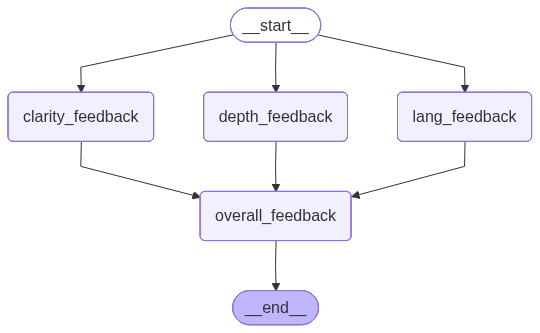

In [186]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [187]:
essay = """Introduction For centuries, the practice of medicine has been defined by the physician’s ability to synthesize fragments of information—symptoms, history, and intuition—into a diagnosis. Today, this human-centric model is encountering a seismic shift. The integration of Artificial Intelligence (AI) into healthcare represents the most significant paradigm shift since the discovery of germ theory. By transitioning from a reactive model of care to a proactive, data-driven discipline, AI promises to democratize expertise and precision. However, this transformation is not merely technological but ethical. The true potential of AI in healthcare lies not in replacing the physician, but in "augmented intelligence"—a symbiosis where algorithms handle data complexity, allowing humans to reclaim the art of patient care.

The Revolution in Diagnostics and Imaging The most immediate and tangible impact of AI is visible in medical imaging. Modern medicine generates petabytes of visual data, from MRIs to CT scans, overwhelming human radiologists. Deep learning algorithms, specifically Convolutional Neural Networks (CNNs), have demonstrated the ability to analyze these images with speed and accuracy often surpassing human experts.

For instance, in the detection of diabetic retinopathy and metastatic breast cancer, AI systems have achieved sensitivity rates that reduce false negatives, ensuring fewer patients slip through the cracks. Unlike a human doctor, who may suffer from fatigue after an eight-hour shift, an algorithm provides the same level of scrutiny to the first patient as it does to the thousandth. This consistency is critical in early detection, where the difference of a few millimeters in a tumor can be the difference between life and death.

Precision Medicine and Accelerated Discovery Beyond diagnostics, AI is the engine driving the era of "precision medicine." Historically, medical treatments were designed for the "average" patient, leading to trial-and-error prescriptions. AI allows for the analysis of a patient's unique genomic profile, lifestyle factors, and environmental data to tailor treatments specifically to the individual.

Furthermore, AI is revolutionizing pharmaceutical research. Traditional drug discovery is a costly odyssey, often requiring over a decade and billions of dollars to bring a single drug to market.


Platforms like DeepMind’s AlphaFold have solved complex biological challenges, such as predicting protein folding structures, which accelerates the identification of drug targets. By simulating how molecules interact in a virtual environment, researchers can screen millions of potential compounds in days rather than years, drastically lowering the cost of innovation and bringing life-saving therapies to patients faster.


Operational Efficiency and the Human Element While high-tech cures grab headlines, AI’s impact on the administrative backend of healthcare is equally profound. Physician burnout is a growing crisis, fueled largely by the burden of electronic health record (EHR) documentation. Natural Language Processing (NLP) tools are now capable of listening to doctor-patient consultations and automatically transcribing and coding notes in real-time. By automating this "digital drudgery," AI liberates physicians to focus on their primary role: connecting with patients. Additionally, predictive analytics help hospitals manage resources by forecasting patient influxes, optimizing bed allocation, and preventing bottlenecks in emergency rooms.



The Ethical Imperative: Bias and the "Black Box" Despite these advancements, the path forward is fraught with ethical peril. AI models are only as unbiased as the data they are trained on. If an algorithm learns from historical medical data that contains systemic biases—such as the under-diagnosis of cardiovascular disease in women or minorities—it will replicate and amplify those biases at scale.

Moreover, there is the challenge of the "Black Box" phenomenon. Deep learning models often arrive at a conclusion via complex internal pathways that are indecipherable to humans. In a high-stakes medical environment, "because the computer said so" is an insufficient justification for a life-altering surgery. Ensuring "explainability"—the ability to understand how an AI reached its decision—is crucial for maintaining trust between the technology, the doctor, and the patient.

Conclusion Artificial Intelligence is not a magic pill that will cure all the ailments of the healthcare system, nor is it a robotic usurper of the physician’s role. It is a powerful instrument—a "force multiplier" that scales human expertise. The "best" future for healthcare involves a partnership where AI manages the science of data, and humans manage the art of healing. To achieve this, we must navigate the implementation of AI with rigor, ensuring that our algorithms are not only smart but also transparent, equitable, and empathetic to the human condition."""

In [188]:
essay1 = '''Title: The Double-Edged Scalpel: The Promise and Perils of AI in Healthcare

Introduction

Medicine has always been an information science. From the scribbled notes of Hippocrates to the genomic sequences of today, the practice of healing relies on the synthesis of data. However, the volume of modern medical data—spanning electronic health records (EHRs), medical imaging, and genetic profiles—has surpassed the cognitive capacity of any single human physician. Enter Artificial Intelligence (AI). No longer just a futuristic concept, AI has become a tangible force in healthcare, acting as a "force multiplier" for medical professionals. While it offers unprecedented opportunities to revolutionize diagnostics, accelerate drug discovery, and personalize treatment, its rapid integration brings profound ethical and operational challenges that must be navigated with care.

The Diagnostic Revolution

One of the most immediate impacts of AI is in diagnostics, particularly within visual fields like radiology, pathology, and dermatology. Machine learning algorithms, specifically deep learning models, excel at pattern recognition. For instance, AI systems can now analyze chest X-rays or mammograms with accuracy rates that rival, and occasionally surpass, human experts. These tools do not suffer from fatigue or distraction, allowing for consistent screening of thousands of images to flag anomalies for human review.



Beyond imaging, AI is shifting healthcare from reactive to predictive. Predictive analytics models can analyze a patient's historical data to forecast life-threatening events like sepsis or heart failure hours before clinical symptoms appear. This "early warning system" allows clinicians to intervene sooner, potentially saving lives and reducing hospital stays.

Accelerating Drug Discovery

Perhaps the most transformative application of AI lies in pharmaceutical research. Traditional drug discovery is a notoriously slow and expensive process, often taking over a decade and billions of dollars to bring a single drug to market. AI is compressing this timeline by simulating biological interactions and predicting how potential drug molecules will behave in the human body.


Platforms like DeepMind’s AlphaFold have solved 50-year-old biological problems by predicting the 3D structures of nearly all known proteins. This capability allows researchers to design drugs "de novo" (from scratch) to target specific disease markers with high precision, rather than relying on trial-and-error screening.


The Era of Personalized Medicine

AI is the key to unlocking true personalized medicine. By integrating a patient's genetic makeup, lifestyle data, and environmental factors, AI models can tailor treatment plans to the individual. In oncology, for example, AI algorithms can analyze the genetic mutations of a tumor to recommend the specific combination of immunotherapies most likely to succeed for that specific patient, moving away from the "one-size-fits-all" approach of chemotherapy.

The Ethical Quagmire and Operational Challenges

Despite these benefits, the integration of AI is fraught with challenges. The most significant is the "Black Box" problem. Many deep learning models function as opaque boxes: data goes in, and a decision comes out, but the internal logic is often indecipherable even to its creators. In high-stakes medical scenarios, a doctor needs to know why an AI recommended a specific surgery or diagnosis to trust it.

Furthermore, AI systems are only as good as the data they are trained on. Historical biases in healthcare delivery can be encoded into algorithms. If an AI is trained predominantly on data from one demographic group, it may fail to diagnose conditions accurately in minority populations. There is also the looming issue of data privacy; training robust models requires massive datasets, raising concerns about the security of sensitive patient information and the potential for re-identification.




Conclusion

AI in healthcare represents a paradigm shift, not merely a technological upgrade. It holds the potential to democratize high-quality diagnostics, drastically reduce the cost of life-saving drugs, and free human clinicians from administrative drudgery to focus on patient care. However, realizing this future requires a "human-in-the-loop" approach. AI should be viewed not as a replacement for the physician, but as a powerful stethoscope for the 21st century—an instrument that, when guided by human empathy and ethical oversight, can hear the signals of disease more clearly than ever before. The future of medicine lies not in AI alone, but in "Augmented Intelligence"—the seamless collaboration between the algorithm and the healer.'''

In [189]:
initial_state = {"essay":essay1}
workflow.invoke(initial_state)

9


{'essay': 'Title: The Double-Edged Scalpel: The Promise and Perils of AI in Healthcare\n\nIntroduction\n\nMedicine has always been an information science. From the scribbled notes of Hippocrates to the genomic sequences of today, the practice of healing relies on the synthesis of data. However, the volume of modern medical data—spanning electronic health records (EHRs), medical imaging, and genetic profiles—has surpassed the cognitive capacity of any single human physician. Enter Artificial Intelligence (AI). No longer just a futuristic concept, AI has become a tangible force in healthcare, acting as a "force multiplier" for medical professionals. While it offers unprecedented opportunities to revolutionize diagnostics, accelerate drug discovery, and personalize treatment, its rapid integration brings profound ethical and operational challenges that must be navigated with care.\n\nThe Diagnostic Revolution\n\nOne of the most immediate impacts of AI is in diagnostics, particularly withi